# Feature Selection - Customers Dataset

## Objective

The objective of this notebook is to identify the most relevant features for machine learning by removing redundant, irrelevant, and highly correlated variables. Feature selection helps reduce model complexity, improve interpretability, minimize overfitting, and enhance predictive performance.

This notebook uses multiple feature selection techniques, including variance analysis, correlation analysis, statistical methods, mutual information, recursive feature elimination, and tree-based feature importance to determine the optimal feature set.

2. Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

from sklearn.feature_selection import (
    VarianceThreshold,
    mutual_info_classif,
    SelectKBest,
    RFE
)

from sklearn.ensemble import RandomForestClassifier

pd.set_option("display.max_columns", None)

3. Load Dataset

In [2]:
df = pd.read_csv("/content/datasets/customers_feature_engineered.csv")

4. Dataset Overview

In [3]:
df.head()

,customer_id,first_name,last_name,email,phone,gender,birth_date,registration_date,loyalty_points,age,age_group,customer_tenure_days,customer_tenure_months,customer_tenure_years,registration_year,registration_quarter,registration_month,registration_weekday,registered_on_weekend,loyalty_segment,loyalty_tier,is_senior,is_young_customer,is_adult,is_long_term_customer,is_new_customer,loyalty_points_per_year,email_domain
0,1,Arjun,Modi,arjun.modi1@gmail.com,9923974559,Female,1971-08-08,2021-03-10,3729,54,46-60,1758,58.6,4.82,2021,1,March,Wednesday,0,VIP,4,0,0,0,0,0,772.05,gmail.com
1,2,Riya,Kapoor,riya.kapoor2@gmail.com,9922842611,Female,1978-01-04,2021-09-04,2326,48,46-60,1580,52.7,4.33,2021,3,September,Saturday,1,VIP,4,0,0,0,0,0,535.94,gmail.com
2,3,Neha,Mehta,neha.mehta3@gmail.com,9758661182,Female,1981-07-04,2021-01-09,1842,44,36-45,1818,60.6,4.98,2021,1,January,Saturday,1,VIP,4,0,0,1,0,0,369.14,gmail.com
3,4,Aarav,Trivedi,aarav.trivedi4@gmail.com,9228681267,Female,1995-08-17,2024-11-09,1116,30,26-35,418,13.9,1.15,2024,4,November,Saturday,1,VIP,4,0,0,1,0,0,962.07,gmail.com
4,5,Neha,Desai,neha.desai5@gmail.com,9251875017,Male,1992-10-17,2022-05-29,3115,33,26-35,1313,43.8,3.60,2022,2,May,Sunday,1,VIP,4,0,0,1,0,0,862.88,gmail.com


In [4]:
df.shape

(5000, 28)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 28 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              5000 non-null   int64  
 1   first_name               5000 non-null   object 
 2   last_name                5000 non-null   object 
 3   email                    5000 non-null   object 
 4   phone                    5000 non-null   int64  
 5   gender                   5000 non-null   object 
 6   birth_date               5000 non-null   object 
 7   registration_date        5000 non-null   object 
 8   loyalty_points           5000 non-null   int64  
 9   age                      5000 non-null   int64  
 10  age_group                5000 non-null   object 
 11  customer_tenure_days     5000 non-null   int64  
 12  customer_tenure_months   5000 non-null   float64
 13  customer_tenure_years    5000 non-null   float64
 14  registration_year       

5. Remove Identifier Columns

In [6]:
drop_columns = [
    "customer_id",
    "first_name",
    "last_name",
    "email",
    "phone"
]

df = df.drop(columns=drop_columns)

6. Select Target Variable

In [7]:
TARGET = "is_long_term_customer"

7. Encode Categorical Features

In [8]:
label_encoder = LabelEncoder()

categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    df[column] = label_encoder.fit_transform(df[column].astype(str))

8. Split Features and Target

In [9]:
X = df.drop(TARGET, axis=1)

y = df[TARGET]

In [19]:
# ===============================
# Data Validation Before Feature Selection
# ===============================

# Keep only numeric columns
X = X.select_dtypes(include=["number"])

# Replace positive and negative infinity with NaN
X.replace([np.inf, -np.inf], np.nan, inplace=True)

# Replace extremely large values that exceed float64
X = X.clip(lower=-1e10, upper=1e10)

# Fill missing values with median
for column in X.columns:
    X[column].fillna(X[column].median(), inplace=True)

# Final validation
print("Shape:", X.shape)
print("Missing Values:", X.isnull().sum().sum())
print("Infinity Values:", np.isinf(X.values).sum())

Shape: (5000, 16)
Missing Values: 0
Infinity Values: 0


/tmp/ipykernel_3034/1966189410.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X[column].fillna(X[column].median(), inplace=True)


9. Low Variance Feature Removal

In [20]:
# ===============================
# Low Variance Feature Removal
# ===============================

from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)

X_variance = selector.fit_transform(X)

selected_columns = X.columns[selector.get_support()]

X = pd.DataFrame(
    X_variance,
    columns=selected_columns,
    index=df.index
)

print("Remaining Features:", len(X.columns))
print(X.columns.tolist())

Remaining Features: 14
['gender', 'birth_date', 'registration_date', 'loyalty_points', 'registration_quarter', 'registration_month', 'registration_weekday', 'registered_on_weekend', 'loyalty_segment', 'loyalty_tier', 'is_young_customer', 'is_adult', 'is_new_customer', 'loyalty_points_per_year']


10. Correlation Analysis

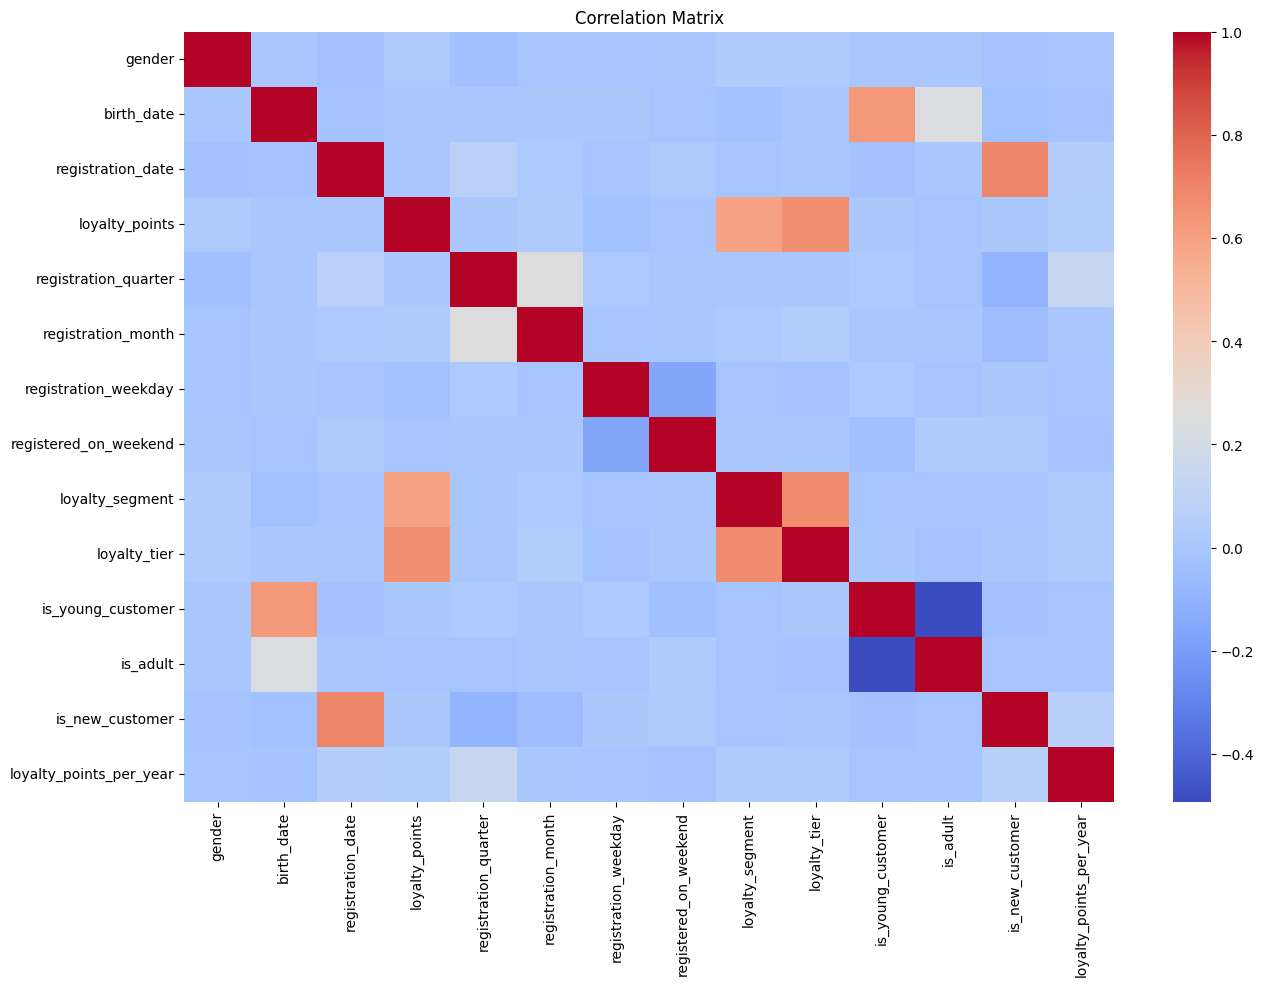

In [21]:
corr = X.corr()

plt.figure(figsize=(15,10))

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

11. Remove Highly Correlated Features

In [22]:
corr_matrix = X.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [
    column
    for column in upper.columns
    if any(upper[column] > 0.90)
]

print(to_drop)

[]


In [23]:
X = X.drop(columns=to_drop)

12. Mutual Information

In [24]:
# ===============================
# Mutual Information
# ===============================

from sklearn.feature_selection import mutual_info_classif

# Safety check
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(X.median(numeric_only=True), inplace=True)

mi_scores = mutual_info_classif(
    X,
    y,
    random_state=42
)

mi = (
    pd.DataFrame({
        "Feature": X.columns,
        "Score": mi_scores
    })
    .sort_values("Score", ascending=False)
    .reset_index(drop=True)
)

print(mi)

                    Feature     Score
0         registration_date  0.433077
1   loyalty_points_per_year  0.107894
2           is_new_customer  0.035991
3           loyalty_segment  0.005074
4            loyalty_points  0.003199
5         is_young_customer  0.002693
6                  is_adult  0.000892
7      registration_quarter  0.000000
8                    gender  0.000000
9                birth_date  0.000000
10       registration_month  0.000000
11             loyalty_tier  0.000000
12     registration_weekday  0.000000
13    registered_on_weekend  0.000000


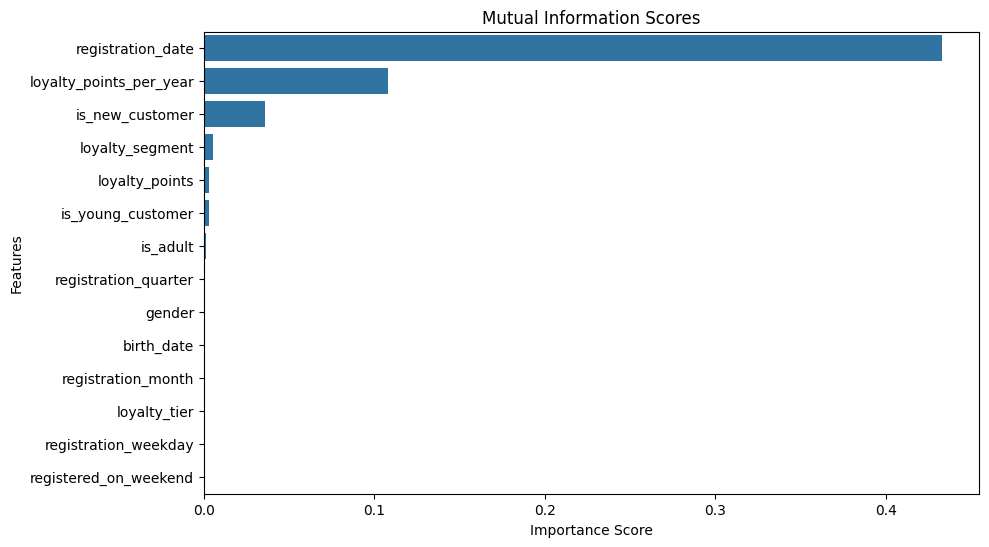

In [33]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=mi,
    x="Score",
    y="Feature"
)

plt.title("Mutual Information Scores")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

13. Select K Best Features

In [35]:
# ===============================
# Select K Best Features
# ===============================

from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import mutual_info_classif

# Safety check
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(X.median(numeric_only=True), inplace=True)

selector = SelectKBest(
    score_func=mutual_info_classif,
    k=10
)

X_selected = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()]

print("Selected Features:")
print(selected_features.tolist())

X_selected = pd.DataFrame(
    X_selected,
    columns=selected_features,
    index=df.index
)

Selected Features:
['gender', 'registration_date', 'registration_quarter', 'registration_weekday', 'loyalty_segment', 'loyalty_tier', 'is_young_customer', 'is_adult', 'is_new_customer', 'loyalty_points_per_year']


14. Recursive Feature Elimination (RFE)

In [36]:
model = RandomForestClassifier(
    random_state=42
)

rfe = RFE(
    estimator=model,
    n_features_to_select=10
)

rfe.fit(X,y)

selected_features = X.columns[
    rfe.support_
]

selected_features

Index(['birth_date', 'registration_date', 'loyalty_points',
       'registration_quarter', 'registration_month', 'registration_weekday',
       'loyalty_segment', 'loyalty_tier', 'is_new_customer',
       'loyalty_points_per_year'],
      dtype='object')

15. Feature Importance using Random Forest

In [37]:
rf = RandomForestClassifier(
    random_state=42
)

rf.fit(X,y)

RandomForestClassifier(random_state=42)

In [38]:
importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
2,registration_date,0.808639
13,loyalty_points_per_year,0.095269
3,loyalty_points,0.041150
12,is_new_customer,0.018945
1,birth_date,0.012536
5,registration_month,0.004953
6,registration_weekday,0.003906
9,loyalty_tier,0.003744
4,registration_quarter,0.003686
8,loyalty_segment,0.003414


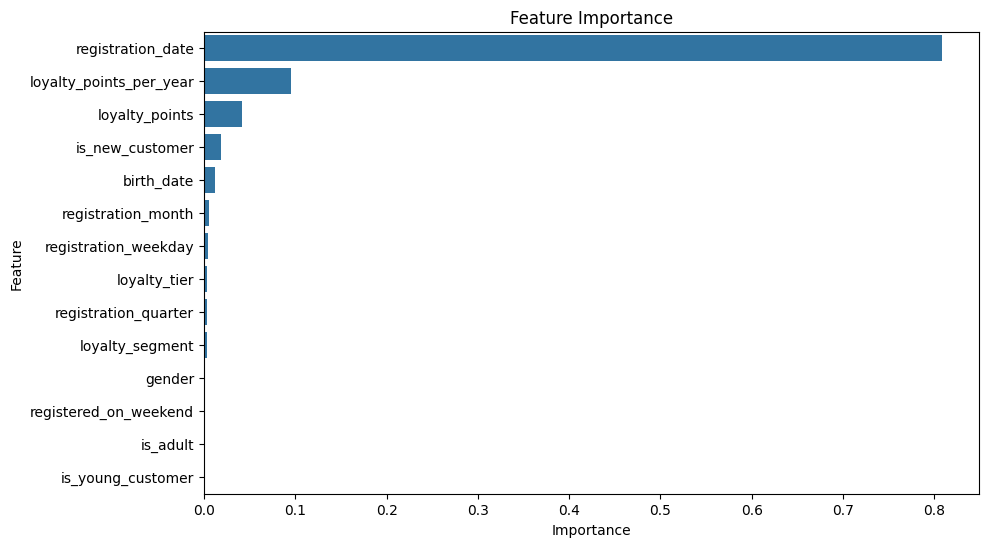

In [39]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.show()

16. Final Feature Selection

In [42]:
final_features = [
    "gender",
    #"age",
    #"customer_tenure_days",
    "loyalty_points",
    "loyalty_tier",
    #"registration_year",
    "registered_on_weekend",
    #"age_group",
    #"registration_season",
    "loyalty_points_per_year"
]

In [43]:
X_final = X[final_features]

17. Save Selected Dataset

In [45]:
X_final.to_csv(
    "datasets/customers_selected_features.csv",
    index=False
)